In [254]:
# Import libraries
import pandas as pd 
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

In [255]:
conn = sqlite3.connect('Level3_final_project_library.db') 

In [256]:
def run (query):
    return pd.read_sql_query(query, conn)

# Task 1

### Get to know the data

In [257]:
run("""
SELECT name 
FROM sqlite_master 
WHERE type='table';
""")

,name
0,members
1,books
2,checkouts


In [258]:
run("""
SELECT * 
FROM members;
""")

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05
1,1002,Fares,Saleh,9.0,Maadi,Active,None
2,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23
3,1004,Fares,Wahba,7.0,Maadi,inactive,2024-10-09
4,1005,Youssef,Halim,9.0,Maadi,Active,2024-05-05
...,...,...,...,...,...,...,...
75,1076,Dina,Wahba,7.0,Shubra,Active,2025-12-13
76,1077,Lina,Rashad,6.0,Shubra,Active,2023-07-08
77,1078,Habiba,Osman,7.0,Shubra,INACTIVE,2023-08-05
78,1079,Rana,Osman,8.0,Shubra,Active,2024-10-27


In [259]:
run("""
SELECT * 
FROM books;
""")

,book_id,title,author
0,501,The Silver Kite,Amina Darwish
1,502,Desert Compass,Amina Darwish
2,503,The Lantern Maker,Adel Roushdy
3,504,Rooftop Astronomers,Adel Roushdy
4,505,Letters to the Nile,Aya Hafez
5,506,The Paper Boat Club,Aya Hafez
6,507,Fossils and Fireflies,Dalia Serry
7,508,The Quiet Observatory,Dalia Serry
8,509,Marbles and Mirrors,Diaa Sultan
9,510,The Missing Metronome,Diaa Sultan


In [260]:
run("""
SELECT * 
FROM checkouts;
""")

,checkout_id,member_id,book_id,checkout_date,return_date
0,9263,1047,517,2024-10-21,2024-11-07
1,9340,1072,513,2025-08-24,2025-09-01
2,9231,1053,523,2024-02-04,2024-02-16
3,9129,1032,513,2025-06-21,2025-06-29
4,9370,1079,511,2025-11-11,2025-12-03
...,...,...,...,...,...
386,9232,1044,513,2025-05-26,2025-06-11
387,9084,1008,511,2024-06-27,2024-07-22
388,9116,1024,519,2025-01-10,2025-02-09
389,9352,1076,501,2025-02-02,None


In [261]:
#Q1
run("""
SELECT first_name , COUNT(book_id) AS checkout_count 
FROM members m 
JOIN checkouts ch 
ON m.member_id = ch.member_id 
GROUP BY m.member_id;
""")



,first_name,checkout_count
0,Salma,1
1,Fares,2
2,Bassel,9
3,Youssef,3
4,Layla,1
...,...,...
57,Malak,9
58,Dina,7
59,Lina,6
60,Rana,10


In [262]:
#Q2
run("""SELECT title , author 
FROM books 
WHERE author LIKE 'A%' ;""")

,title,author
0,The Silver Kite,Amina Darwish
1,Desert Compass,Amina Darwish
2,The Lantern Maker,Adel Roushdy
3,Rooftop Astronomers,Adel Roushdy
4,Letters to the Nile,Aya Hafez
5,The Paper Boat Club,Aya Hafez


In [263]:
#Q3
run("""
SELECT title , COUNT(b.book_id) AS checkout_count
FROM books b 
JOIN checkouts ch ON 
b.book_id = ch.book_id 
GROUP BY title 
ORDER BY checkout_count DESC 
LIMIT 5;
""")


,title,checkout_count
0,The Silver Kite,57
1,Fossils and Fireflies,55
2,Circuits for Beginners,46
3,Kites Over Cairo,38
4,Storms and Sailboats,25


In [264]:
#Q4
run("""
SELECT first_name , COUNT(book_id) AS checkout_count 
FROM members m 
JOIN checkouts ch 
ON m.member_id = ch.member_id 
GROUP BY m.member_id
ORDER BY checkout_count DESC 
LIMIT 10 ;
""")

,first_name,checkout_count
0,Aya,25
1,Sherif,21
2,Ziad,19
3,Mostafa,18
4,Nour,18
5,Adam,17
6,Youssef,17
7,Ahmed,17
8,Sara,16
9,Reem,16


In [265]:
#Q5
run("""
SELECT first_name , neighborhood , checkout_id ,checkout_date
FROM members m
JOIN checkouts ch 
ON m.member_id = ch.member_id 
WHERE neighborhood ='Maadi'
ORDER BY checkout_date DESC 
LIMIT 10 OFFSET 10
""")

,first_name,neighborhood,checkout_id,checkout_date
0,Bassel,Maadi,9103,2025-09-04
1,Adam,Maadi,9081,2025-08-25
2,Ziad,Maadi,9001,2025-08-23
3,Bassel,Maadi,9050,2025-08-21
4,Ahmed,Maadi,9085,2025-08-19
5,Hamza,Maadi,9055,2025-08-08
6,Ahmed,Maadi,9023,2025-08-04
7,Ziad,Maadi,9004,2025-07-27
8,Bassel,Maadi,9051,2025-07-22
9,Hassan,Maadi,9010,2025-07-22


In [266]:
t1 = run("""
            SELECT * 
            FROM members    
                       """)

t2 = run("""
            SELECT * 
            FROM checkouts    
                       """)
combined_tables = pd.merge(t1, t2 ,on='member_id', how='outer' )

In [267]:
combined_tables['checkout_count'] = combined_tables.groupby('member_id')['checkout_id'].transform('count')

In [268]:
combined_tables

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,checkout_count
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05,9025.0,525.0,2024-10-24,2024-11-07,1
1,1002,Fares,Saleh,9.0,Maadi,Active,None,9013.0,501.0,2024-02-16,2024-02-29,2
2,1002,Fares,Saleh,9.0,Maadi,Active,None,9095.0,507.0,2024-06-25,2024-07-07,2
3,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9051.0,513.0,2025-07-22,2025-08-18,9
4,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9068.0,501.0,2025-11-14,2025-12-03,9
...,...,...,...,...,...,...,...,...,...,...,...,...
404,1079,Rana,Osman,8.0,Shubra,Active,2024-10-27,9381.0,507.0,2025-05-30,2025-06-18,10
405,1079,Rana,Osman,8.0,Shubra,Active,2024-10-27,9367.0,507.0,2024-03-19,2024-03-28,10
406,1079,Rana,Osman,8.0,Shubra,Active,2024-10-27,9373.0,508.0,2024-03-20,2024-04-19,10
407,1080,Bassel,Wahba,9.0,Shubra,Active,2023-12-28,9350.0,501.0,2025-06-22,2025-07-17,2


In [269]:
combined_tables.isna().sum()

member_id             0
first_name            0
last_name             0
grade                38
neighborhood          0
membership_status     0
join_date             6
checkout_id          18
book_id              18
checkout_date        18
return_date          83
checkout_count        0
dtype: int64

In [270]:
combined_tables.shape

(409, 12)

In [271]:
catalog = pd.read_json("Book Catalog.json")

In [272]:
combined_tables_catalog = pd.merge(combined_tables , catalog , on='book_id', how='left')
combined_tables_catalog

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,checkout_count,genre,pages,publication_year,publisher
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05,9025.0,525.0,2024-10-24,2024-11-07,1,Adventure,297.0,2015.0,Oasis Books
1,1002,Fares,Saleh,9.0,Maadi,Active,None,9013.0,501.0,2024-02-16,2024-02-29,2,Adventure,128.0,2017.0,Nile Press
2,1002,Fares,Saleh,9.0,Maadi,Active,None,9095.0,507.0,2024-06-25,2024-07-07,2,Science,160.0,2024.0,Nile Press
3,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9051.0,513.0,2025-07-22,2025-08-18,9,Science,294.0,2021.0,Oasis Books
4,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9068.0,501.0,2025-11-14,2025-12-03,9,Adventure,128.0,2017.0,Nile Press
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,1079,Rana,Osman,8.0,Shubra,Active,2024-10-27,9381.0,507.0,2025-05-30,2025-06-18,10,Science,160.0,2024.0,Nile Press
405,1079,Rana,Osman,8.0,Shubra,Active,2024-10-27,9367.0,507.0,2024-03-19,2024-03-28,10,Science,160.0,2024.0,Nile Press
406,1079,Rana,Osman,8.0,Shubra,Active,2024-10-27,9373.0,508.0,2024-03-20,2024-04-19,10,Science,306.0,2011.0,Oasis Books
407,1080,Bassel,Wahba,9.0,Shubra,Active,2023-12-28,9350.0,501.0,2025-06-22,2025-07-17,2,Adventure,128.0,2017.0,Nile Press


In [273]:
combined_tables_catalog.shape

(409, 16)

In [274]:
kickoffs = pd.read_html("Reading Kickoff Signups.html")[0]
kickoffs.columns = ["member_id" ,"book_id" , "checkout_date" ]


full_kickoffs =  pd.merge(kickoffs,t1 , on = "member_id" , how = "left")
full_kickoffs =  pd.merge(full_kickoffs,catalog , on = "book_id" , how = "left")
combined_data = pd.concat([combined_tables_catalog , full_kickoffs] , ignore_index= True)

combined_data['checkout_count'] = combined_data.groupby('member_id')['checkout_date'].transform('count')

In [275]:
kickoffs

,member_id,book_id,checkout_date
0,1026,522,2025-07-11
1,1049,520,2025-07-11
2,1062,525,2025-07-05
3,1065,520,2025-07-07
4,1104,515,2025-07-07
5,1009,503,2025-07-09
6,1063,522,2025-07-07
7,1022,511,2025-07-12
8,1029,523,2025-07-09
9,1201,509,2025-07-10


In [276]:
combined_data

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,checkout_count,genre,pages,publication_year,publisher
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05,9025.0,525.0,2024-10-24,2024-11-07,1,Adventure,297.0,2015.0,Oasis Books
1,1002,Fares,Saleh,9.0,Maadi,Active,None,9013.0,501.0,2024-02-16,2024-02-29,3,Adventure,128.0,2017.0,Nile Press
2,1002,Fares,Saleh,9.0,Maadi,Active,None,9095.0,507.0,2024-06-25,2024-07-07,3,Science,160.0,2024.0,Nile Press
3,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9051.0,513.0,2025-07-22,2025-08-18,10,Science,294.0,2021.0,Oasis Books
4,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9068.0,501.0,2025-11-14,2025-12-03,10,Adventure,128.0,2017.0,Nile Press
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,NaN,501.0,2025-07-08,NaN,10,Adventure,128.0,2017.0,Nile Press
431,1017,Adam,Badr,9.0,Maadi,Active,2025-07-12,NaN,507.0,2025-07-11,NaN,3,Science,160.0,2024.0,Nile Press
432,1061,Ziad,Fahmy,9.0,zamalek,Inactive,2023-04-27,NaN,504.0,2025-07-06,NaN,10,Science,319.0,2009.0,Cairo Young Readers
433,1201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,523.0,2025-07-08,NaN,2,Historical,276.0,2018.0,Oasis Books


In [277]:
combined_data.to_csv("30801151901074-library-task1_combined_data.csv" , index = False)

# Task 2 

#### Explore the data

In [278]:
data = pd.read_csv("30801151901074-library-task1_combined_data.csv")

In [279]:
data.head()

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,checkout_count,genre,pages,publication_year,publisher
0,1001,Salma,Ibrahim,8.0,Maadi,Active,2023-04-05,9025.0,525.0,2024-10-24,2024-11-07,1,Adventure,297.0,2015.0,Oasis Books
1,1002,Fares,Saleh,9.0,Maadi,Active,NaN,9013.0,501.0,2024-02-16,2024-02-29,3,Adventure,128.0,2017.0,Nile Press
2,1002,Fares,Saleh,9.0,Maadi,Active,NaN,9095.0,507.0,2024-06-25,2024-07-07,3,Science,160.0,2024.0,Nile Press
3,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9051.0,513.0,2025-07-22,2025-08-18,10,Science,294.0,2021.0,Oasis Books
4,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,9068.0,501.0,2025-11-14,2025-12-03,10,Adventure,128.0,2017.0,Nile Press


In [280]:
data.tail()

,member_id,first_name,last_name,grade,neighborhood,membership_status,join_date,checkout_id,book_id,checkout_date,return_date,checkout_count,genre,pages,publication_year,publisher
430,1003,Bassel,Hegazy,6.0,Maadi,Active,2025-04-23,NaN,501.0,2025-07-08,NaN,10,Adventure,128.0,2017.0,Nile Press
431,1017,Adam,Badr,9.0,Maadi,Active,2025-07-12,NaN,507.0,2025-07-11,NaN,3,Science,160.0,2024.0,Nile Press
432,1061,Ziad,Fahmy,9.0,zamalek,Inactive,2023-04-27,NaN,504.0,2025-07-06,NaN,10,Science,319.0,2009.0,Cairo Young Readers
433,1201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,523.0,2025-07-08,NaN,2,Historical,276.0,2018.0,Oasis Books
434,1041,Nada,Rashad,7.0,Nasr City,Active,2024-04-02,NaN,512.0,2025-07-06,NaN,4,Adventure,238.0,2022.0,Delta House


In [281]:
data.shape

(435, 16)

In [282]:
data.describe()

,member_id,grade,checkout_id,book_id,checkout_count,pages,publication_year
count,435.000000,392.000000,391.000000,417.000000,435.000000,417.000000,382.000000
mean,1041.117241,7.545918,9192.611253,513.443645,11.480460,202.299760,2017.426702
std,26.126819,1.156737,110.279771,8.976053,7.220775,73.986738,4.567214
min,1001.000000,6.000000,9001.000000,501.000000,0.000000,104.000000,2009.000000
25%,1020.000000,6.000000,9097.500000,507.000000,5.500000,134.000000,2014.000000
50%,1038.000000,8.000000,9193.000000,513.000000,10.000000,160.000000,2017.000000
75%,1061.000000,9.000000,9287.500000,519.000000,18.000000,294.000000,2021.000000
max,1201.000000,9.000000,9383.000000,532.000000,25.000000,338.000000,2024.000000


In [283]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   member_id          435 non-null    int64  
 1   first_name         430 non-null    object 
 2   last_name          430 non-null    object 
 3   grade              392 non-null    float64
 4   neighborhood       430 non-null    object 
 5   membership_status  430 non-null    object 
 6   join_date          423 non-null    object 
 7   checkout_id        391 non-null    float64
 8   book_id            417 non-null    float64
 9   checkout_date      417 non-null    object 
 10  return_date        326 non-null    object 
 11  checkout_count     435 non-null    int64  
 12  genre              417 non-null    object 
 13  pages              417 non-null    float64
 14  publication_year   382 non-null    float64
 15  publisher          417 non-null    object 
dtypes: float64(5), int64(2), o

In [284]:
print(data.columns.tolist())

['member_id', 'first_name', 'last_name', 'grade', 'neighborhood', 'membership_status', 'join_date', 'checkout_id', 'book_id', 'checkout_date', 'return_date', 'checkout_count', 'genre', 'pages', 'publication_year', 'publisher']


In [285]:
data.duplicated().sum()

np.int64(8)

In [286]:
# Duplicates first cause it could lead to less nulls 
data_cleaned = data.drop_duplicates(keep="first").copy()

In [287]:
data_cleaned.duplicated().sum()

np.int64(0)

In [288]:
data_cleaned.isna().sum()

member_id              0
first_name             5
last_name              5
grade                 43
neighborhood           5
membership_status      5
join_date             12
checkout_id           44
book_id               18
checkout_date         18
return_date          109
checkout_count         0
genre                 18
pages                 18
publication_year      51
publisher             18
dtype: int64

In [289]:
data_cleaned.tail(26).isna().sum()

member_id             0
first_name            5
last_name             5
grade                 5
neighborhood          5
membership_status     5
join_date             6
checkout_id          26
book_id               0
checkout_date         0
return_date          26
checkout_count        0
genre                 0
pages                 0
publication_year      1
publisher             0
dtype: int64

### Deal with nulls from kickoffs data

In [290]:
# Fill return date 
data_cleaned["return_date"] = pd.to_datetime(data_cleaned["return_date"])
kickoffs_return_date = data_cleaned["return_date"].isna() & data_cleaned["checkout_id"].isna()
data_cleaned.loc[kickoffs_return_date , "return_date"] = pd.Timestamp('2025-08-31')

In [291]:
# Filling the checkout_id 
latest_id = data_cleaned["checkout_id"].max()
missing_mask = data_cleaned["checkout_id"].isna() & data_cleaned["book_id"].notna()
missing_ids = missing_mask.sum()
data_cleaned.loc[missing_mask,"checkout_id"] = (range(int(latest_id) + 1 , int(latest_id) + 1 + missing_ids))

In [292]:
data_cleaned[["checkout_date" , "join_date","return_date"]].tail(26).isna().sum()

checkout_date    0
join_date        6
return_date      0
dtype: int64

In [293]:
data_cleaned["grade"].value_counts()

grade
9.0    112
6.0     95
7.0     93
8.0     84
Name: count, dtype: int64

### Deal with whole data nulls

In [294]:
# Fill grades according proportionally so we no artificial bias happen
grade_probs = data_cleaned["grade"].value_counts(normalize=True)
missing_mask = data_cleaned["grade"].isna()
missing_count = missing_mask.sum()

prob_groups = np.random.choice(
grade_probs.index , 
size = missing_count,
p = grade_probs.values

)
data_cleaned.loc[missing_mask,"grade"] = prob_groups

data_cleaned["grade"].isna().sum()

np.int64(0)

In [295]:
# fill neighborhood as unknown which is safer to don't fabricate or make an artificial bias  
data_cleaned["neighborhood"] = data_cleaned["neighborhood"].fillna("Unknown")
data_cleaned["neighborhood"].isna().sum()

np.int64(0)

In [296]:
# fill join date
data_cleaned["checkout_date"] = pd.to_datetime(data_cleaned["checkout_date"])
real_member = data_cleaned["first_name"].notna()
join_missing = data_cleaned["join_date"].isna() & real_member
first_checkout = data_cleaned.groupby("member_id")["checkout_date"].transform("min")
data_cleaned.loc[join_missing, "join_date"] = first_checkout[join_missing]

In [297]:
data_cleaned["publication_year"] = data_cleaned.groupby("book_id")["publication_year"].transform(lambda x: x.ffill().bfill())
checkout_mask = data_cleaned["publication_year"].isna() & data_cleaned["book_id"].notna()
#Fill publication_year with median of publication_year of the author 
publisher_median = data_cleaned.groupby("publisher")["publication_year"].transform("median")
data_cleaned.loc[checkout_mask,"publication_year"] = data_cleaned["publication_year"].fillna(publisher_median)

#In case the user has a nulls of publication year so calculate with global median 
overall_median = data_cleaned["publication_year"].median()
data_cleaned.loc[checkout_mask,"publication_year"] = data_cleaned["publication_year"].fillna(overall_median)


In [298]:
# Some values can't be just filled 
data_cleaned.isna().sum()

member_id             0
first_name            5
last_name             5
grade                 0
neighborhood          0
membership_status     5
join_date             6
checkout_id          18
book_id              18
checkout_date        18
return_date          65
checkout_count        0
genre                18
pages                18
publication_year     18
publisher            18
dtype: int64

### Data consistency

In [299]:
print(data_cleaned.columns.tolist())

['member_id', 'first_name', 'last_name', 'grade', 'neighborhood', 'membership_status', 'join_date', 'checkout_id', 'book_id', 'checkout_date', 'return_date', 'checkout_count', 'genre', 'pages', 'publication_year', 'publisher']


In [300]:
data_cleaned["neighborhood"].value_counts()

neighborhood
Nasr City     104
Maadi          97
Heliopolis     90
Zamalek        62
Shubra         35
Maadi          20
zamalek        10
Unknown         5
HELIOPOLIS      2
Nasr  City      1
NASR CITY       1
Name: count, dtype: int64

In [301]:
 # Data unification (making it consistent)
data_cleaned["neighborhood"] = data_cleaned["neighborhood"].str.lower().str.strip().str.title()
data_cleaned["neighborhood"] = data_cleaned["neighborhood"].replace("Nasr  City","Nasr City").str.title()

In [302]:
data_cleaned["neighborhood"].value_counts()

neighborhood
Maadi         117
Nasr City     106
Heliopolis     92
Zamalek        72
Shubra         35
Unknown         5
Name: count, dtype: int64

In [303]:
data_cleaned["membership_status"].value_counts()

membership_status
Active      290
Inactive     53
active       46
inactive     32
INACTIVE      1
Name: count, dtype: int64

In [304]:
data_cleaned["membership_status"] = data_cleaned["membership_status"].str.lower().str.strip().str.title()

In [305]:
data_cleaned["membership_status"].value_counts()

membership_status
Active      336
Inactive     86
Name: count, dtype: int64

In [306]:
data_cleaned["first_name"].value_counts()

first_name
Ahmed      32
Ziad       31
Youssef    28
Aya        26
Mostafa    25
Sherif     25
Adam       24
Rana       20
Lina       18
Fares      18
Nour       18
Nada       16
Sara       16
Dina       16
Reem       16
Seif       14
Bassel     13
Layla      11
Malak       9
Tarek       8
Retaj       8
Hassan      6
Ali         3
Hamza       3
Yassin      3
Jana        2
Menna       2
Karim       2
Habiba      2
Amir        2
Salma       1
Hana        1
Marwan      1
Mai         1
Farida      1
Name: count, dtype: int64

In [307]:
data_cleaned["first_name"].value_counts().tail(18)

first_name
Layla     11
Malak      9
Tarek      8
Retaj      8
Hassan     6
Ali        3
Hamza      3
Yassin     3
Jana       2
Menna      2
Karim      2
Habiba     2
Amir       2
Salma      1
Hana       1
Marwan     1
Mai        1
Farida     1
Name: count, dtype: int64

In [308]:
data_cleaned["last_name"].value_counts()

last_name
Fahmy      54
Saleh      50
Fouad      42
Wahba      39
Hegazy     36
Rashad     35
Osman      28
Adel       26
Zaki       24
Shafik     22
Nabil      20
Halim      14
Kamel      11
Mansour     6
Ibrahim     4
Sabry       4
Badr        3
Riad        2
Gamal       2
Name: count, dtype: int64

In [309]:
data_cleaned["genre"].value_counts()

genre
Science            112
Adventure          110
Friendship          61
Mystery             44
Historical          32
Nature              23
Science Fiction     21
Poetry               6
Name: count, dtype: int64

In [310]:
data_cleaned["publisher"].value_counts()

publisher
Nile Press             203
Oasis Books            112
Cairo Young Readers     53
Delta House             41
Name: count, dtype: int64

In [311]:
# Outliers Checker
pages_total_outliers = []
q1 = pd.Series(data_cleaned["pages"]).quantile(0.25)
q3 = pd.Series(data_cleaned["pages"]).quantile(0.75)
IQR = q3-q1
upperfence = q3+1.5*IQR
lowerfence = max(0,q1-1.5*IQR)

for x in data_cleaned["pages"] :
  if x > upperfence or x < lowerfence:
    pages_total_outliers.append(x)
print(f"Outliers of coulmn pages are:{pages_total_outliers}")

grade_outliers = []
q1 = pd.Series(data_cleaned["grade"]).quantile(0.25)
q3 = pd.Series(data_cleaned["grade"]).quantile(0.75)
IQR = q3-q1
upperfence = q3+1.5*IQR
lowerfence = max(0,q1-1.5*IQR)

for x in data_cleaned["grade"] :
  if x > upperfence or x < lowerfence:
    grade_outliers.append(x)
print(f"Outliers of coulmn grade are:{grade_outliers}")


checkout_count_outliers = []
q1 = pd.Series(data_cleaned["checkout_count"]).quantile(0.25)
q3 = pd.Series(data_cleaned["checkout_count"]).quantile(0.75)
IQR = q3-q1
upperfence = q3+1.5*IQR
lowerfence = max(0,q1-1.5*IQR)

for x in data_cleaned["checkout_count"] :
  if x > upperfence or x < lowerfence:
    checkout_count_outliers.append(x)
print(f"Outliers of coulmn customer_age are:{checkout_count_outliers}")


Outliers of coulmn pages are:[]
Outliers of coulmn grade are:[]
Outliers of coulmn customer_age are:[]


In [312]:
unmatched_ids = data_cleaned.loc[data_cleaned["first_name"].isna(), "member_id"].unique()
print(f"Unmatched member_ids ({len(unmatched_ids)}): {unmatched_ids}")

Unmatched member_ids (3): [1104 1201 1150]


In [313]:
data_cleaned.isna().sum()

member_id             0
first_name            5
last_name             5
grade                 0
neighborhood          0
membership_status     5
join_date             6
checkout_id          18
book_id              18
checkout_date        18
return_date          65
checkout_count        0
genre                18
pages                18
publication_year     18
publisher            18
dtype: int64

In [314]:
data_cleaned.to_csv("30801151901074-library-task2_cleaned_data.csv" , index = False)

In [315]:
members_of_neighborhood = data_cleaned.groupby("neighborhood")["member_id"].nunique()
members_of_neighborhood 

neighborhood
Heliopolis    18
Maadi         22
Nasr City     20
Shubra         6
Unknown        3
Zamalek       14
Name: member_id, dtype: int64

In [316]:
checkouts_of_neighborhood = data_cleaned.groupby("neighborhood")["checkout_date"].count()
checkouts_of_neighborhood

neighborhood
Heliopolis     87
Maadi         114
Nasr City     101
Shubra         34
Unknown         5
Zamalek        68
Name: checkout_date, dtype: int64

C:\Users\Mosta\AppData\Local\Temp\ipykernel_13072\3825473823.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


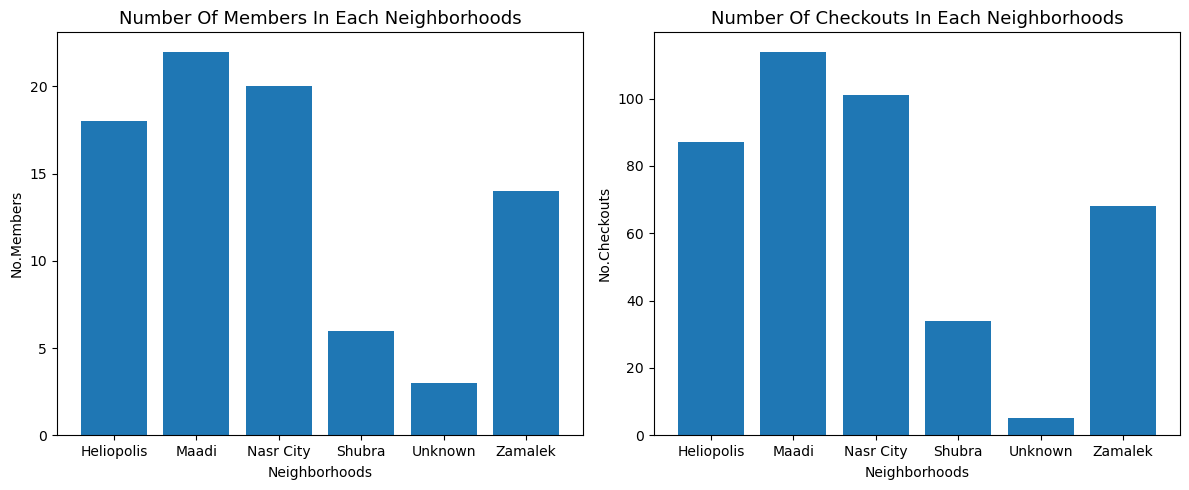

In [317]:
fig , (ax1,ax2) = plt.subplots(1,2, figsize = (12,5))

ax1.bar(members_of_neighborhood.index , members_of_neighborhood .values)
ax1.set_title("Number Of Members In Each Neighborhoods" , fontsize = 13 )
ax1.set_xlabel("Neighborhoods", labelpad = 5)
ax1.set_ylabel("No.Members")

ax2.bar(checkouts_of_neighborhood.index , checkouts_of_neighborhood .values)
ax2.set_title("Number Of Checkouts In Each Neighborhoods", fontsize = 13)
ax2.set_xlabel("Neighborhoods", labelpad = 5 )
ax2.set_ylabel("No.Checkouts")

fig.tight_layout()
fig.show()